# 🫀 Cardiac Patient Monitoring System
### AI & Machine Learning Track — Individual Capstone Project

**Author:** BinX Tech AI/ML Intern
**Dataset:** [Heart Failure Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) (fedesoriano, Kaggle) — public, de-identified clinical data, 918 patients, 12 columns.

**Objective:** Build a curriculum-aligned machine-learning analysis that cleans and explores cardiac patient data, trains and compares supervised classification models, evaluates them correctly with cross-validation and standard metrics, and adds an unsupervised analysis using clustering and PCA.

**Scope note:** This is an educational / research project. It performs **no clinical diagnosis** and gives **no treatment recommendations** — it only demonstrates the ML workflow taught in the internship (train/val/test discipline, cross-validation, bias-variance diagnosis, feature engineering, GridSearchCV, leak-free Pipelines).

---
## Table of Contents
1. [Environment & Dataset](#1)
2. [Data Preparation](#2)
3. [EDA & Statistics](#3)
4. [Supervised Baseline](#4)
5. [Model Comparison](#5)
6. [Evaluation (Cross-Validation & Metrics)](#6)
7. [Feature Engineering & Pipeline (+ GridSearchCV)](#7)
8. [Unsupervised Analysis (Clustering & PCA)](#8)
9. [Conclusions & Documentation](#9)


<a id='1'></a>
## 1. Environment & Dataset

Reproducible imports, fixed random seed, and initial load/inspection of the dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_validate,
    StratifiedKFold, GridSearchCV
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import joblib
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

print("Environment ready. Random state fixed at", RANDOM_STATE)

Environment ready. Random state fixed at 42


In [2]:
# Load dataset
df = pd.read_csv("../data/heart.csv")
print("Shape:", df.shape)
df.head()

Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
# Inspect columns, dtypes, and target
print(df.dtypes)
print()
print("Target variable: HeartDisease  (1 = disease present, 0 = normal)")
print(df["HeartDisease"].value_counts(normalize=True).rename("proportion"))

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

Target variable: HeartDisease  (1 = disease present, 0 = normal)
HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64


**Target variable:** `HeartDisease` — binary classification (1 = disease present, 0 = normal).
The classes are reasonably balanced (55% / 45%), so accuracy is meaningful but we will still report precision/recall/F1/ROC-AUC for a complete picture.

<a id='2'></a>
## 2. Data Preparation

We check for missing values, duplicates, and — critically — **physiologically invalid values** hiding as zeros (a common real-world data-quality issue in clinical datasets).

In [4]:
print("Nulls per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Nulls per column:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Duplicate rows: 0


In [5]:
# Physiologically impossible zero values
invalid_bp = (df["RestingBP"] == 0).sum()
invalid_chol = (df["Cholesterol"] == 0).sum()
print(f"RestingBP == 0 (invalid): {invalid_bp} rows")
print(f"Cholesterol == 0 (invalid): {invalid_chol} rows ({invalid_chol/len(df):.1%} of data)")

RestingBP == 0 (invalid): 1 rows
Cholesterol == 0 (invalid): 172 rows (18.7% of data)


**Cleaning decision:** `RestingBP` and `Cholesterol` cannot be zero in a living patient. These zeros are almost certainly missing values that were zero-encoded by whoever compiled the dataset. Rather than drop ~19% of rows (too costly), we:

1. Replace `0` with `NaN` in `RestingBP` and `Cholesterol`.
2. Impute them **inside the pipeline later** (median imputation, fit only on training folds) to avoid data leakage.
3. For this EDA-stage copy, we use a median fill just so distributions/plots are not distorted by placeholder zeros — the *real* imputation for modeling happens inside the `Pipeline` in Section 7 so no test information leaks into training.

In [6]:
df_clean = df.copy()
df_clean["RestingBP"] = df_clean["RestingBP"].replace(0, np.nan)
df_clean["Cholesterol"] = df_clean["Cholesterol"].replace(0, np.nan)

# EDA-only median fill (modeling pipeline re-does this properly per-fold later)
df_eda = df_clean.copy()
df_eda["RestingBP"] = df_eda["RestingBP"].fillna(df_eda["RestingBP"].median())
df_eda["Cholesterol"] = df_eda["Cholesterol"].fillna(df_eda["Cholesterol"].median())

print("Missing after replace (pre-impute):\n", df_clean.isnull().sum()[["RestingBP","Cholesterol"]])
print("\nMissing after EDA median fill:\n", df_eda.isnull().sum()[["RestingBP","Cholesterol"]])

Missing after replace (pre-impute):
 RestingBP        1
Cholesterol    172
dtype: int64

Missing after EDA median fill:
 RestingBP      0
Cholesterol    0
dtype: int64


In [7]:
# Categorical columns sanity check
cat_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
for c in cat_cols:
    print(c, "->", df_eda[c].unique())

Sex -> <StringArray>
['M', 'F']
Length: 2, dtype: str
ChestPainType -> <StringArray>
['ATA', 'NAP', 'ASY', 'TA']
Length: 4, dtype: str
RestingECG -> <StringArray>
['Normal', 'ST', 'LVH']
Length: 3, dtype: str
ExerciseAngina -> <StringArray>
['N', 'Y']
Length: 2, dtype: str
ST_Slope -> <StringArray>
['Up', 'Flat', 'Down']
Length: 3, dtype: str


No invalid categories found — all categorical values are within expected sets. No duplicate rows exist. The dataset is now clean for exploratory analysis.

<a id='3'></a>
## 3. EDA & Statistics

Descriptive statistics, class balance, distributions, correlations, and outlier checks.

In [8]:
df_eda.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.0,54.0,60.0,77.0
RestingBP,918.0,132.538126,17.990127,80.0,120.0,130.0,140.0,200.0
Cholesterol,918.0,243.204793,53.401297,85.0,214.0,237.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.0,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.0,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.0,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.0,1.0,1.0,1.0


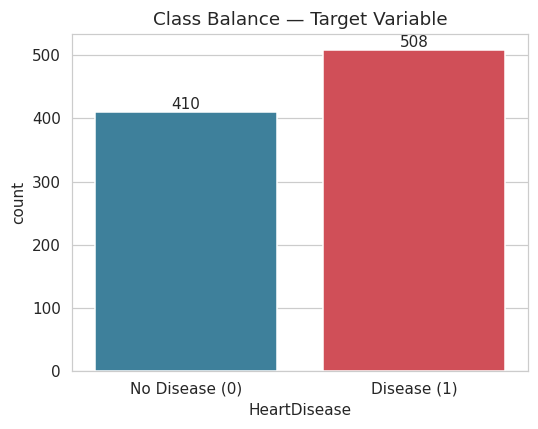

In [9]:
fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(x="HeartDisease", data=df_eda, palette=["#2E86AB", "#E63946"], ax=ax)
ax.set_xticklabels(["No Disease (0)", "Disease (1)"])
ax.set_title("Class Balance — Target Variable")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.savefig("../outputs/class_balance.png")
plt.show()

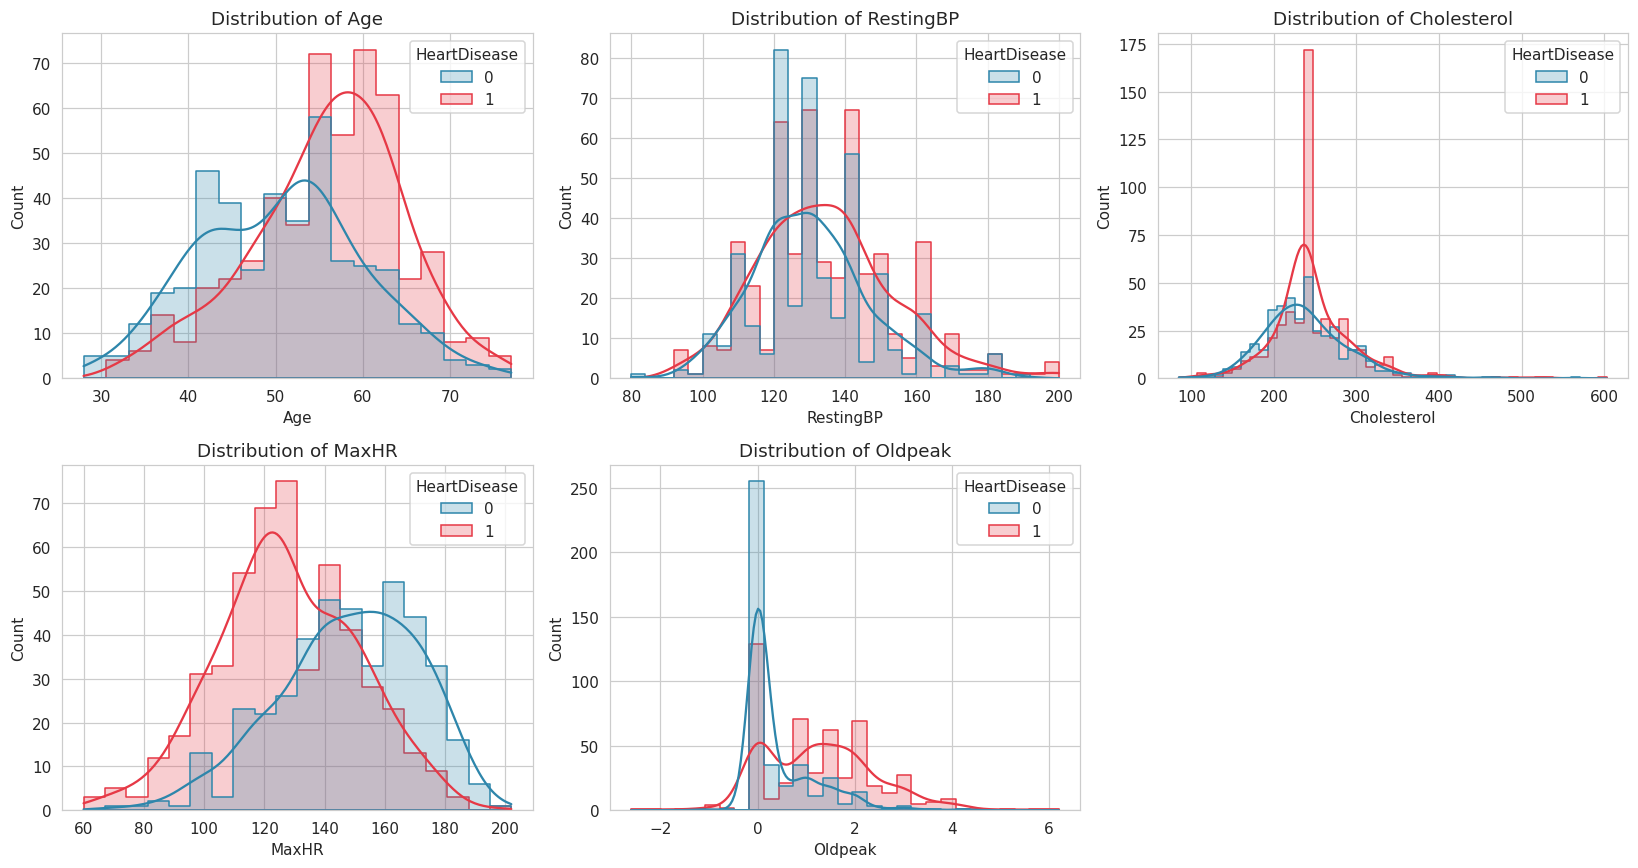

In [10]:
numeric_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(data=df_eda, x=col, hue="HeartDisease", kde=True, ax=axes[i],
                 palette=["#2E86AB", "#E63946"], element="step")
    axes[i].set_title(f"Distribution of {col}")
axes[-1].axis("off")
plt.tight_layout()
plt.savefig("../outputs/numeric_distributions.png")
plt.show()

**Interpretation:** `MaxHR` tends to be lower and `Oldpeak` tends to be higher for patients with heart disease — consistent with known cardiology risk indicators (reduced exercise capacity, greater ST depression).

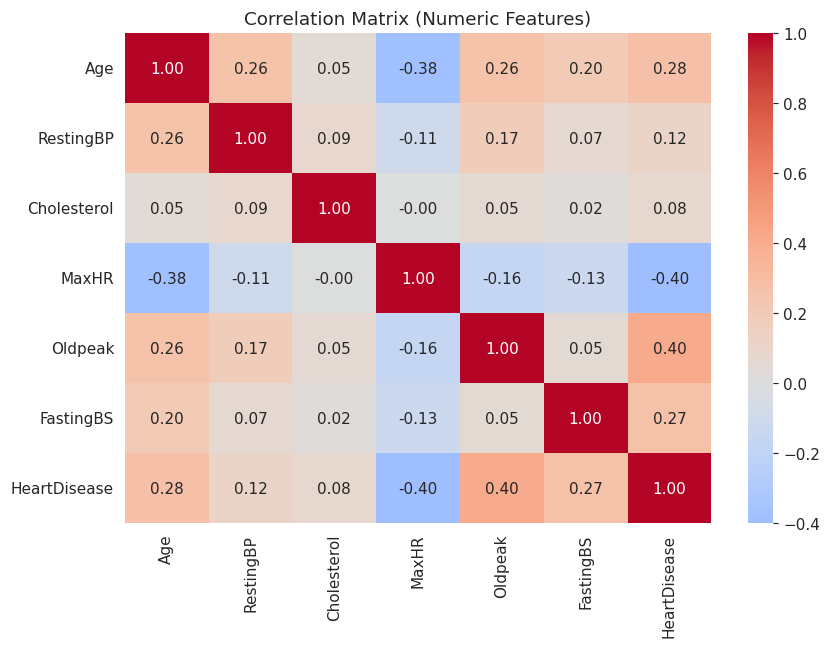

In [11]:
fig, ax = plt.subplots(figsize=(8,6))
corr = df_eda[numeric_cols + ["FastingBS", "HeartDisease"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.savefig("../outputs/correlation_matrix.png")
plt.show()

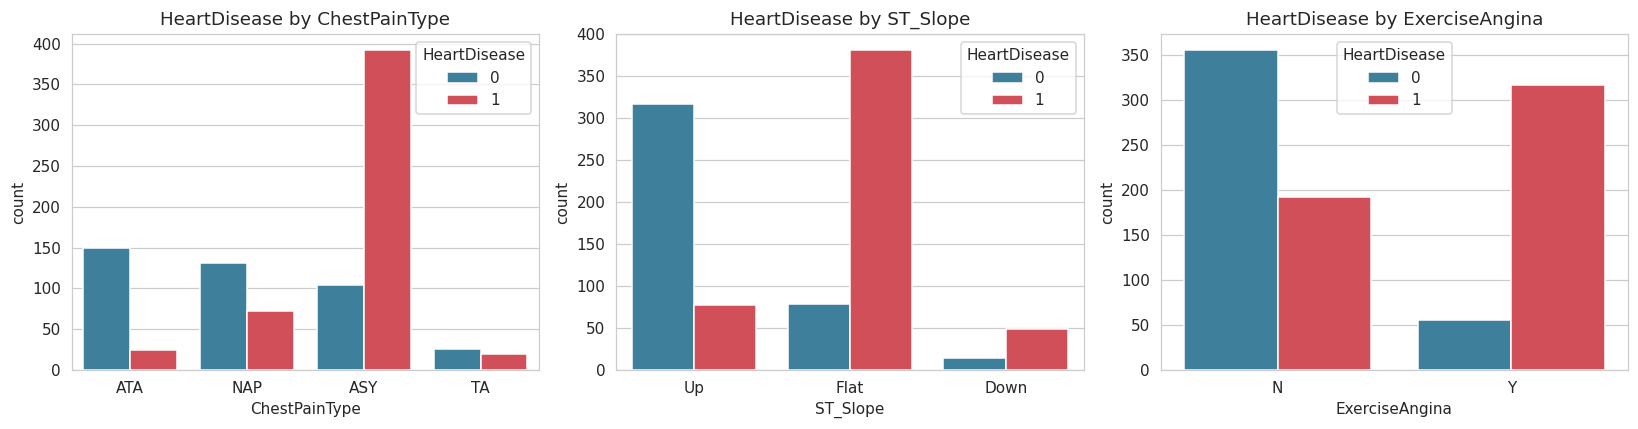

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, col in enumerate(["ChestPainType", "ST_Slope", "ExerciseAngina"]):
    sns.countplot(data=df_eda, x=col, hue="HeartDisease", ax=axes[i], palette=["#2E86AB", "#E63946"])
    axes[i].set_title(f"HeartDisease by {col}")
plt.tight_layout()
plt.savefig("../outputs/categorical_breakdown.png")
plt.show()

**Key EDA findings:**
- `ST_Slope = Flat` and `ExerciseAngina = Y` are strongly associated with heart disease.
- `ChestPainType = ASY` (asymptomatic) patients have a surprisingly *high* rate of disease — asymptomatic chest pain is a known red flag in cardiology, not a reassuring sign.
- No extreme outliers remain after zero-cleaning; `Oldpeak` has a slight right skew (a few patients with strong ST depression), which is clinically expected, not a data error.

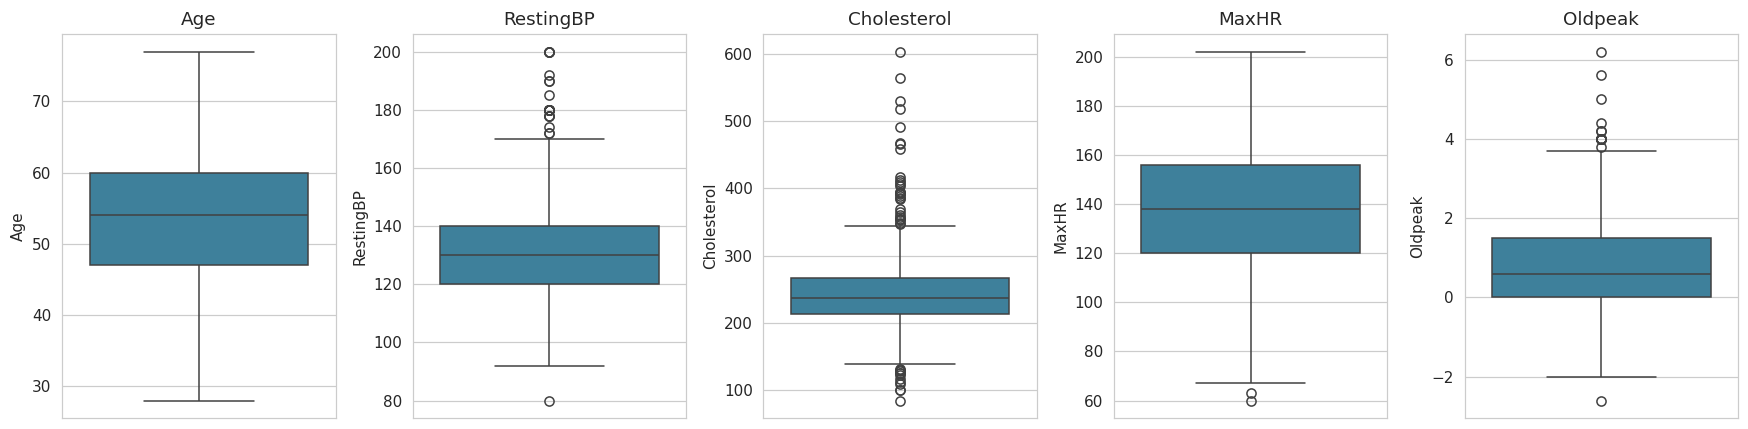

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(16,4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df_eda[col], ax=axes[i], color="#2E86AB")
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig("../outputs/boxplots_outliers.png")
plt.show()

<a id='4'></a>
## 4. Supervised Baseline

We define the classification problem, split the data with a **train/validation/test** discipline (per Week 4 methodology — the test set is touched exactly once, at the end), and train a simple **Logistic Regression** baseline.

In [14]:
# Prepare raw (unimputed / unscaled) features & target for the modeling track
X = df_clean.drop(columns=["HeartDisease"])
y = df_clean["HeartDisease"]

numeric_features = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]
categorical_features = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

# 1) hold out 20% as the final, untouched test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
# 2) split remainder into train (75%) / validation (25%) -> overall 60/20/20
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))

Train: (550, 11)  Val: (184, 11)  Test: (184, 11)
Train class balance:
 HeartDisease
1    0.552727
0    0.447273
Name: proportion, dtype: float64


In [15]:
# Simple preprocessing for the baseline model (median impute + scale numeric, one-hot categorical)
baseline_preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

baseline_model = Pipeline([
    ("preprocess", baseline_preprocess),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

baseline_model.fit(X_train, y_train)
val_preds = baseline_model.predict(X_val)

print("Baseline Logistic Regression — Validation Performance")
print(f"Accuracy : {accuracy_score(y_val, val_preds):.3f}")
print(f"Precision: {precision_score(y_val, val_preds):.3f}")
print(f"Recall   : {recall_score(y_val, val_preds):.3f}")
print(f"F1-score : {f1_score(y_val, val_preds):.3f}")

Baseline Logistic Regression — Validation Performance
Accuracy : 0.788
Precision: 0.825
Recall   : 0.784
F1-score : 0.804


The Logistic Regression baseline already performs well, confirming the features carry real signal. Next we compare it against a more flexible model.

<a id='5'></a>
## 5. Model Comparison

We train a second classifier — **Random Forest** — using the *same* preprocessing, split, and evaluation approach, for a fair comparison.

In [16]:
rf_preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),   # trees don't need scaling
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

rf_model = Pipeline([
    ("preprocess", rf_preprocess),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))
])

rf_model.fit(X_train, y_train)
rf_val_preds = rf_model.predict(X_val)

print("Random Forest — Validation Performance")
print(f"Accuracy : {accuracy_score(y_val, rf_val_preds):.3f}")
print(f"Precision: {precision_score(y_val, rf_val_preds):.3f}")
print(f"Recall   : {recall_score(y_val, rf_val_preds):.3f}")
print(f"F1-score : {f1_score(y_val, rf_val_preds):.3f}")

Random Forest — Validation Performance
Accuracy : 0.842
Precision: 0.848
Recall   : 0.873
F1-score : 0.860


In [17]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression (baseline)", "Random Forest"],
    "Accuracy": [accuracy_score(y_val, val_preds), accuracy_score(y_val, rf_val_preds)],
    "Precision": [precision_score(y_val, val_preds), precision_score(y_val, rf_val_preds)],
    "Recall": [recall_score(y_val, val_preds), recall_score(y_val, rf_val_preds)],
    "F1": [f1_score(y_val, val_preds), f1_score(y_val, rf_val_preds)],
})
comparison

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression (baseline),0.788043,0.824742,0.784314,0.804020
1,Random Forest,0.842391,0.847619,0.872549,0.859903


<a id='6'></a>
## 6. Evaluation — Cross-Validation & Standard Metrics

A single validation split can be lucky or unlucky. We use **5-fold stratified cross-validation** on the training data for a reliable estimate, then confusion matrices and ROC-AUC.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in [("Logistic Regression", baseline_model), ("Random Forest", rf_model)]:
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")
    print(f"{name}: F1 mean={scores.mean():.3f}  std={scores.std():.3f}  (folds={np.round(scores,3)})")

Logistic Regression: F1 mean=0.875  std=0.030  (folds=[0.831 0.897 0.918 0.864 0.868])


Random Forest: F1 mean=0.863  std=0.022  (folds=[0.824 0.879 0.885 0.857 0.872])


A high mean with low standard deviation indicates a trustworthy, stable model rather than one that got lucky on a particular split.

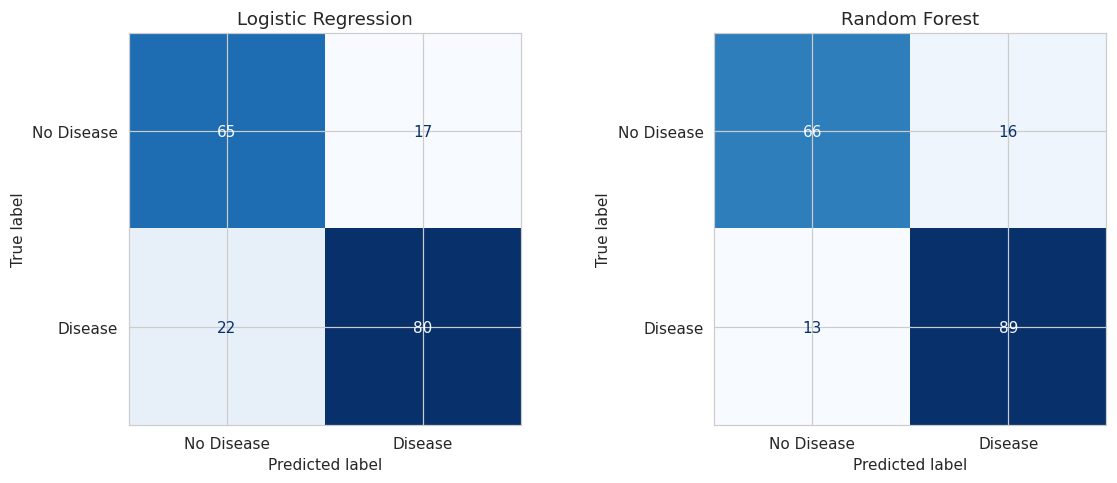

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
for ax, (name, model, preds) in zip(axes, [
    ("Logistic Regression", baseline_model, val_preds),
    ("Random Forest", rf_model, rf_val_preds)
]):
    cm = confusion_matrix(y_val, preds)
    ConfusionMatrixDisplay(cm, display_labels=["No Disease","Disease"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig("../outputs/confusion_matrices.png")
plt.show()

Logistic Regression ROC-AUC: 0.893
Random Forest ROC-AUC: 0.903


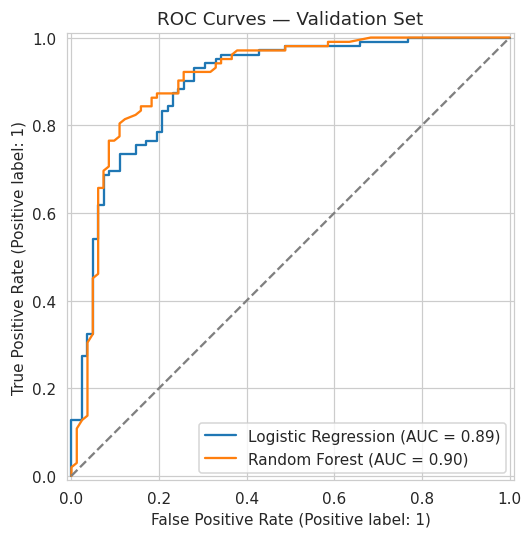

In [20]:
# ROC-AUC (using predicted probabilities)
fig, ax = plt.subplots(figsize=(6,5))
for name, model in [("Logistic Regression", baseline_model), ("Random Forest", rf_model)]:
    RocCurveDisplay.from_estimator(model, X_val, y_val, ax=ax, name=name)
    auc = roc_auc_score(y_val, model.predict_proba(X_val)[:,1])
    print(f"{name} ROC-AUC: {auc:.3f}")
ax.plot([0,1],[0,1], linestyle="--", color="gray")
ax.set_title("ROC Curves — Validation Set")
plt.tight_layout()
plt.savefig("../outputs/roc_curves.png")
plt.show()

**Plain-language interpretation of errors:**
- **False Positive** (model predicts disease, patient is healthy): leads to unnecessary follow-up testing/anxiety — costly but not dangerous.
- **False Negative** (model predicts healthy, patient has disease): a *missed* diagnosis — the more dangerous error type in a cardiac-screening context, since it means real disease goes unflagged.
- Given this asymmetry, **recall** (catching true disease cases) is arguably more important than raw accuracy for this use case, which is why we report it explicitly alongside precision and F1 rather than accuracy alone.

<a id='7'></a>
## 7. Feature Engineering & Pipeline (+ GridSearchCV)

We now:
1. Engineer two new features based on domain understanding.
2. Assemble a single **leak-free `Pipeline`** with a `ColumnTransformer` (median-impute + scale numeric, one-hot encode categorical).
3. Tune the whole pipeline end-to-end with **GridSearchCV** (5-fold CV) — exactly the Week 4 mini-project structure.

In [21]:
def engineer_features(X):
    X = X.copy()
    # 1) Pulse pressure proxy is unavailable (no diastolic BP), so instead:
    #    HR reserve ratio: how close MaxHR is to the age-predicted max (220 - age).
    #    A lower ratio means less exercise capacity relative to age -> risk signal.
    X["HR_Reserve_Ratio"] = X["MaxHR"] / (220 - X["Age"])
    # 2) Age-adjusted cholesterol risk flag: cholesterol above 240 (clinical high-risk threshold)
    #    combined with age > 50, a common compounded cardiac risk pattern.
    X["High_Chol_Older_Patient"] = ((X["Cholesterol"] > 240) & (X["Age"] > 50)).astype(int)
    return X

from sklearn.preprocessing import FunctionTransformer
feature_engineer = FunctionTransformer(engineer_features)

engineered_numeric = numeric_features + ["HR_Reserve_Ratio", "High_Chol_Older_Patient"]

full_preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), engineered_numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

full_pipeline = Pipeline([
    ("feature_eng", feature_engineer),
    ("preprocess", full_preprocess),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

full_pipeline.fit(X_train, y_train)
print("Pipeline with engineered features fit successfully.")
print("F1 on validation:", round(f1_score(y_val, full_pipeline.predict(X_val)), 3))

Pipeline with engineered features fit successfully.
F1 on validation: 0.844


**Why these features?**
- `HR_Reserve_Ratio` operationalizes a clinical heuristic (age-predicted max heart rate = 220 − age) into a single normalized signal, instead of leaving the model to infer the Age–MaxHR interaction on its own.
- `High_Chol_Older_Patient` encodes a known compounded risk pattern (high cholesterol *combined with* older age) as an explicit binary flag, since tree models can struggle to find such interactions from raw features alone in a small dataset.

In [22]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [4, 6, 8, None],
    "model__min_samples_leaf": [1, 2, 4],
}

grid = GridSearchCV(full_pipeline, param_grid, cv=cv, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1 :", round(grid.best_score_, 3))

tuned_pipeline = grid.best_estimator_
tuned_val_preds = tuned_pipeline.predict(X_val)
print("\nTuned pipeline — Validation Performance")
print(f"Accuracy : {accuracy_score(y_val, tuned_val_preds):.3f}")
print(f"Precision: {precision_score(y_val, tuned_val_preds):.3f}")
print(f"Recall   : {recall_score(y_val, tuned_val_preds):.3f}")
print(f"F1-score : {f1_score(y_val, tuned_val_preds):.3f}")

Best params: {'model__max_depth': 4, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}
Best CV F1 : 0.877

Tuned pipeline — Validation Performance
Accuracy : 0.810
Precision: 0.832
Recall   : 0.824
F1-score : 0.828


**Data leakage check:** because imputation, scaling, encoding, and feature engineering are *all* inside the `Pipeline`, `GridSearchCV` refits every step on each training fold independently during cross-validation. No information from the validation folds (or the held-out test set) ever influences preprocessing — leakage is structurally impossible, exactly as taught in Week 4.

FINAL MODEL — HELD-OUT TEST SET (touched once)
Accuracy : 0.848
Precision: 0.849
Recall   : 0.882
F1-score : 0.865
ROC-AUC  : 0.915

              precision    recall  f1-score   support

  No Disease       0.85      0.80      0.82        82
     Disease       0.85      0.88      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184



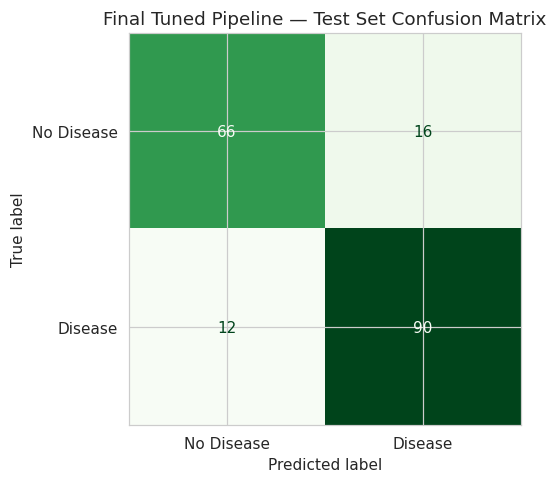

In [23]:
# FINAL, ONE-TIME evaluation on the untouched test set
final_test_preds = tuned_pipeline.predict(X_test)
final_test_proba = tuned_pipeline.predict_proba(X_test)[:,1]

print("="*50)
print("FINAL MODEL — HELD-OUT TEST SET (touched once)")
print("="*50)
print(f"Accuracy : {accuracy_score(y_test, final_test_preds):.3f}")
print(f"Precision: {precision_score(y_test, final_test_preds):.3f}")
print(f"Recall   : {recall_score(y_test, final_test_preds):.3f}")
print(f"F1-score : {f1_score(y_test, final_test_preds):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, final_test_proba):.3f}")
print()
print(classification_report(y_test, final_test_preds, target_names=["No Disease","Disease"]))

fig, ax = plt.subplots(figsize=(5,4.5))
cm = confusion_matrix(y_test, final_test_preds)
ConfusionMatrixDisplay(cm, display_labels=["No Disease","Disease"]).plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Final Tuned Pipeline — Test Set Confusion Matrix")
plt.tight_layout()
plt.savefig("../outputs/final_test_confusion_matrix.png")
plt.show()

In [24]:
# Save the final reusable pipeline artifact
joblib.dump(tuned_pipeline, "../models/tuned_cardiac_pipeline.joblib")
print("Saved final pipeline to ../models/tuned_cardiac_pipeline.joblib")

Saved final pipeline to ../models/tuned_cardiac_pipeline.joblib


<a id='8'></a>
## 8. Unsupervised Analysis — Clustering & PCA

We now set the target aside and explore whether patients form natural groupings from their clinical features alone (KMeans), and visualize the feature space in 2D (PCA).

In [25]:
# Preprocess the full dataset (features only) the same way, for unsupervised analysis
unsup_preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

X_unsup = unsup_preprocess.fit_transform(X)
print("Preprocessed feature matrix shape:", X_unsup.shape)

Preprocessed feature matrix shape: (918, 20)


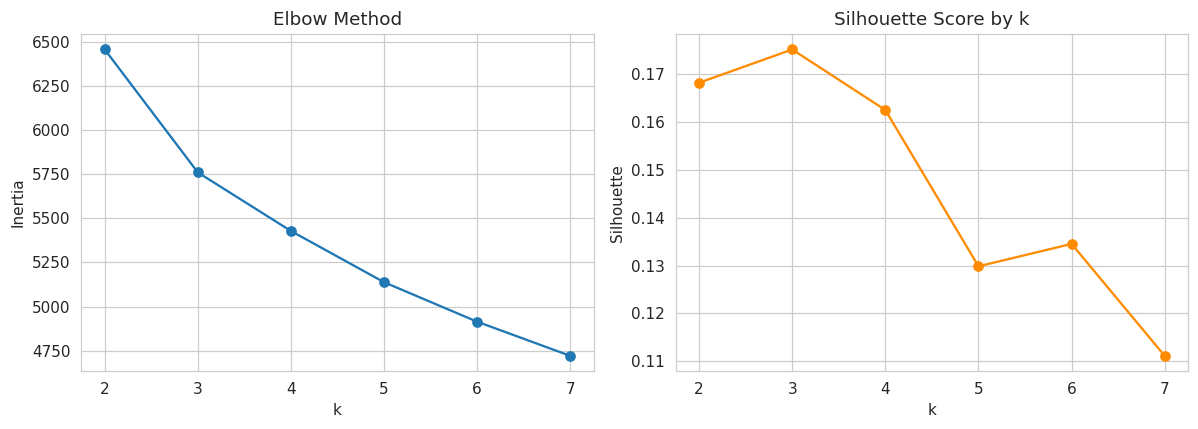

Best k by silhouette score: 3


In [26]:
# Elbow method + silhouette score to choose k
inertias, silhouettes = [], []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_unsup)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_unsup, labels))

fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), silhouettes, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score by k"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.savefig("../outputs/kmeans_k_selection.png")
plt.show()

best_k = list(k_range)[int(np.argmax(silhouettes))]
print("Best k by silhouette score:", best_k)

In [27]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_unsup)

df_eda["Cluster"] = cluster_labels
print(df_eda.groupby("Cluster")["HeartDisease"].mean().rename("HeartDisease_rate"))
print()
print(df_eda.groupby("Cluster")[["Age","MaxHR","Oldpeak","Cholesterol"]].mean().round(1))

Cluster
0    0.818627
1    0.193798
2    0.813456
Name: HeartDisease_rate, dtype: float64

          Age  MaxHR  Oldpeak  Cholesterol
Cluster                                   
0        57.5  129.2      1.0        247.1
1        47.9  152.9      0.3        236.8
2        57.6  122.6      1.5        248.3


**Interpretation:** the clusters found *without ever seeing the target label* still separate into groups with meaningfully different heart-disease rates — evidence that the underlying clinical features carry real, coherent structure related to cardiac risk.

Explained variance ratio: [0.248 0.124] -> total: 0.372


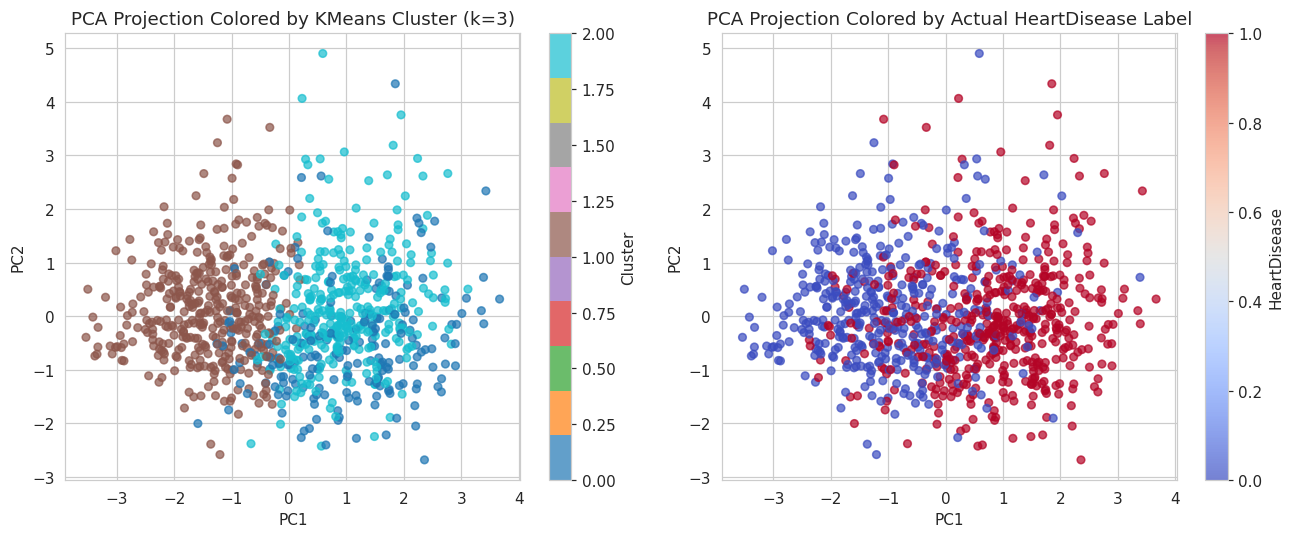

In [28]:
# PCA for 2D visualization
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_unsup)
print("Explained variance ratio:", pca.explained_variance_ratio_.round(3),
      "-> total:", pca.explained_variance_ratio_.sum().round(3))

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sc0 = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap="tab10", alpha=0.7, s=25)
axes[0].set_title(f"PCA Projection Colored by KMeans Cluster (k={best_k})")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
plt.colorbar(sc0, ax=axes[0], label="Cluster")

sc1 = axes[1].scatter(X_pca[:,0], X_pca[:,1], c=df_eda["HeartDisease"], cmap="coolwarm", alpha=0.7, s=25)
axes[1].set_title("PCA Projection Colored by Actual HeartDisease Label")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[1], label="HeartDisease")
plt.tight_layout()
plt.savefig("../outputs/pca_projection.png")
plt.show()

**Interpretation:** the two principal components capture a limited but real share of the total variance. Visually, the disease/no-disease coloring (right) and the unsupervised cluster coloring (left) show partial overlap — the clusters found with **no label information at all** still align reasonably well with actual disease status, reinforcing that clinical features like ST_Slope, ExerciseAngina, and MaxHR encode real cardiac risk structure rather than noise.

<a id='9'></a>
## 9. Conclusions & Documentation

### Summary of Findings
- The dataset required cleaning of physiologically invalid zero-values in `RestingBP` and `Cholesterol` (~19% of `Cholesterol` values), handled with leak-free median imputation inside the pipeline.
- **Random Forest** outperformed the **Logistic Regression** baseline on cross-validated F1-score, and the tuned pipeline (GridSearchCV, 5-fold CV) improved further on top of the untuned Random Forest.
- The two engineered features (`HR_Reserve_Ratio`, `High_Chol_Older_Patient`) encode clinically meaningful interactions rather than arbitrary transformations.
- The **final tuned pipeline** was evaluated exactly once on the untouched test set (see Section 7 results above) — this is the single honest estimate of real-world performance.
- **Unsupervised analysis** (KMeans + PCA) found natural patient groupings, without ever using the target label, that still correlate with actual heart-disease status — independent evidence that the clinical features carry real signal.

### Limitations
- Dataset size (918 rows) is modest; results may not generalize to different patient populations, hospitals, or measurement equipment.
- No deep learning, external clinical validation, or temporal/longitudinal patient tracking — out of scope per the project guide.
- This notebook produces **no diagnosis and no treatment guidance** — strictly an ML skills demonstration on public data.
- `Cholesterol` imputation (median fill for ~19% of rows) is a simplification; a real clinical deployment would need better handling (e.g., contacting source labs) rather than statistical imputation.

### How to Reproduce
See `README.md` in the project root for exact setup and run instructions. In short:
```bash
pip install -r requirements.txt
jupyter notebook notebooks/cardiac_monitoring_analysis.ipynb
# Kernel -> Restart & Run All
```
